# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from environments.optimal_stopping import OptimalStoppingEnv
from function_approximation.linear_fa import LinearFA
from function_approximation.polynomial_fa import PolynomialFA
from algorithms.rpi import RPI
from algorithms.crpi import CRPI
from utils import solve_tabular_pi

In [2]:
import cvxpy as cp
print(f"Installed solvers: {cp.installed_solvers()}")


Installed solvers: ['CLARABEL', 'ECOS', 'ECOS_BB', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']


In [3]:
# --- CELL 2 ---
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Environment Setup
env = OptimalStoppingEnv(N=60, cost=0.05)
gamma = 0.9
iters = 50
d_features = 4
n_seeds = 10  # We run 10 seeds here to generate the shaded regions

P, R = env.get_mdp_matrices()
SA = P.shape[0] * P.shape[1]
nu = np.ones((SA, 1)) / SA

# Get the true optimal baseline using Tabular PI
_, Q_opt = solve_tabular_pi(env, gamma)
optimal_return = (nu.T @ Q_opt).item()

# 2. Execute Training
rpi_all_true, crpi_all_true = [], []
rpi_seed0_true, rpi_seed0_est = None, None
crpi_seed0_true, crpi_seed0_est = None, None

Running 10 seeds for Cell 2. This may take a moment...
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 comp

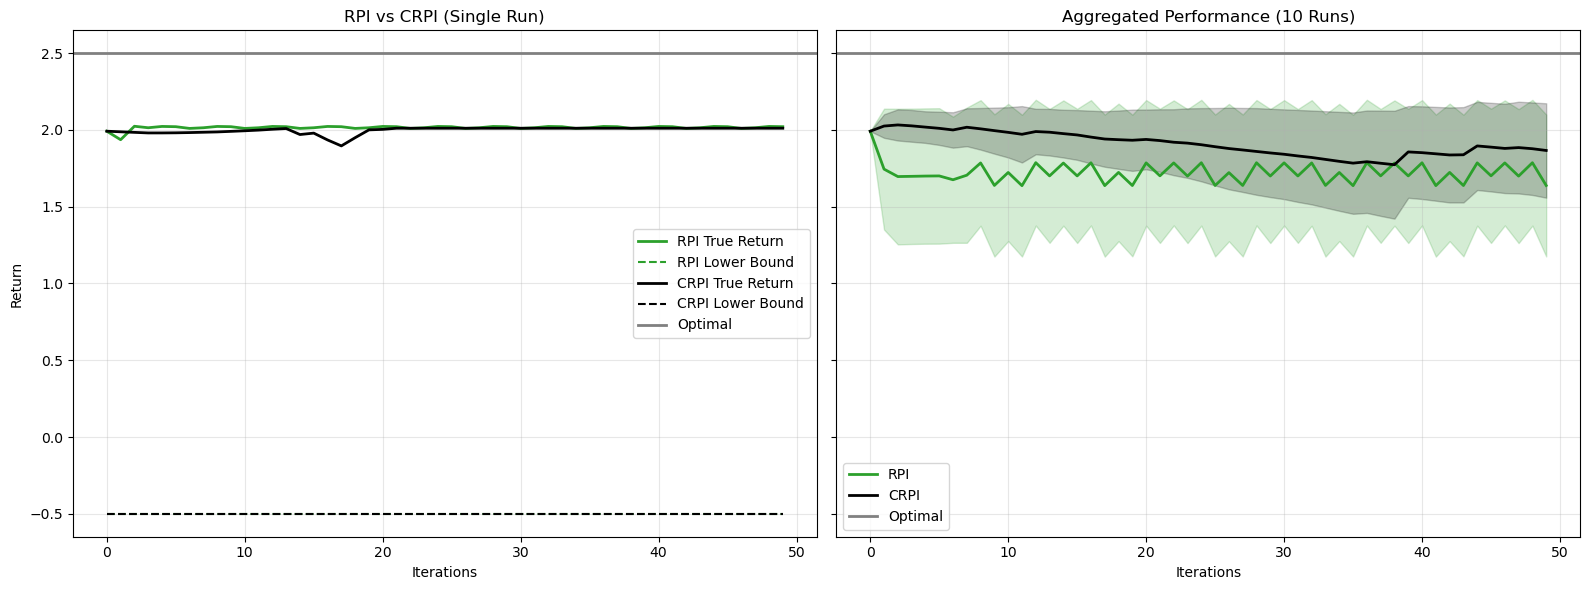

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,84.3 ± 19.4,1.64 ± 0.46
1,CRPI,93.5 ± 9.3,1.87 ± 0.31


In [ ]:
print(f"Running {n_seeds} seeds for Cell 2. This may take a moment...")

for seed in range(n_seeds):
    np.random.seed(seed)
    Phi = np.random.uniform(1, 5, size=(SA, d_features))
    Phi[:, 0] = 1.0 # Bias column to prevent infeasibility

    # Train RPI
    rpi_agent = RPI(env, LinearFA(Phi), gamma, iters)
    _, _, r_hist = rpi_agent.train(track_metrics=True)
    rpi_all_true.append(r_hist['true_return'])

    # Train CRPI
    crpi_agent = CRPI(env, LinearFA(Phi), gamma, iters)
    _, _, c_hist = crpi_agent.train(track_metrics=True)
    crpi_all_true.append(c_hist['true_return'])

    # Save the very first seed's history for the single-run plot
    if seed == 0:
        rpi_seed0_true = r_hist['true_return']
        rpi_seed0_est = r_hist['est_return']
        crpi_seed0_true = c_hist['true_return']
        crpi_seed0_est = c_hist['est_return']

rpi_all_true = np.array(rpi_all_true)
crpi_all_true = np.array(crpi_all_true)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Subplot 1: Single Run (RPI vs CRPI overlay)
ax1.plot(rpi_seed0_true, color='#2ca02c', label='RPI True Return', linewidth=2)
ax1.plot(rpi_seed0_est, color='#2ca02c', linestyle='--', label='RPI Lower Bound')
ax1.plot(crpi_seed0_true, color='#000000', label='CRPI True Return', linewidth=2)
ax1.plot(crpi_seed0_est, color='#000000', linestyle='--', label='CRPI Lower Bound')
ax1.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')

ax1.set_title("RPI vs CRPI (Single Run)")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Return")
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Aggregated Performance (Mean ± 1 Std Dev)
rpi_mean = np.mean(rpi_all_true, axis=0)
rpi_std = np.std(rpi_all_true, axis=0)
crpi_mean = np.mean(crpi_all_true, axis=0)
crpi_std = np.std(crpi_all_true, axis=0)

ax2.plot(rpi_mean, color='#2ca02c', label='RPI', linewidth=2)
ax2.fill_between(range(iters), rpi_mean - rpi_std, rpi_mean + rpi_std, color='#2ca02c', alpha=0.2)
ax2.plot(crpi_mean, color='#000000', label='CRPI', linewidth=2)
ax2.fill_between(range(iters), crpi_mean - crpi_std, crpi_mean + crpi_std, color='#000000', alpha=0.2)
ax2.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')

ax2.set_title(f"Aggregated Performance ({n_seeds} Runs)")
ax2.set_xlabel("Iterations")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Generate Metrics Table using trapezoid
rpi_aucs = [np.trapezoid(run) for run in rpi_all_true]
crpi_aucs = [np.trapezoid(run) for run in crpi_all_true]

data = {
    "Algorithm": ["RPI", "CRPI"],
    "AUC (mean ± std)": [f"{np.mean(rpi_aucs):.1f} ± {np.std(rpi_aucs):.1f}",
                         f"{np.mean(crpi_aucs):.1f} ± {np.std(crpi_aucs):.1f}"],
    "Terminal Perf. (mean ± std)": [f"{rpi_mean[-1]:.2f} ± {rpi_std[-1]:.2f}",
                                    f"{crpi_mean[-1]:.2f} ± {crpi_std[-1]:.2f}"]
}
df = pd.DataFrame(data)
display(df)

Running 6 detailed runs. This will take a moment...
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 complet

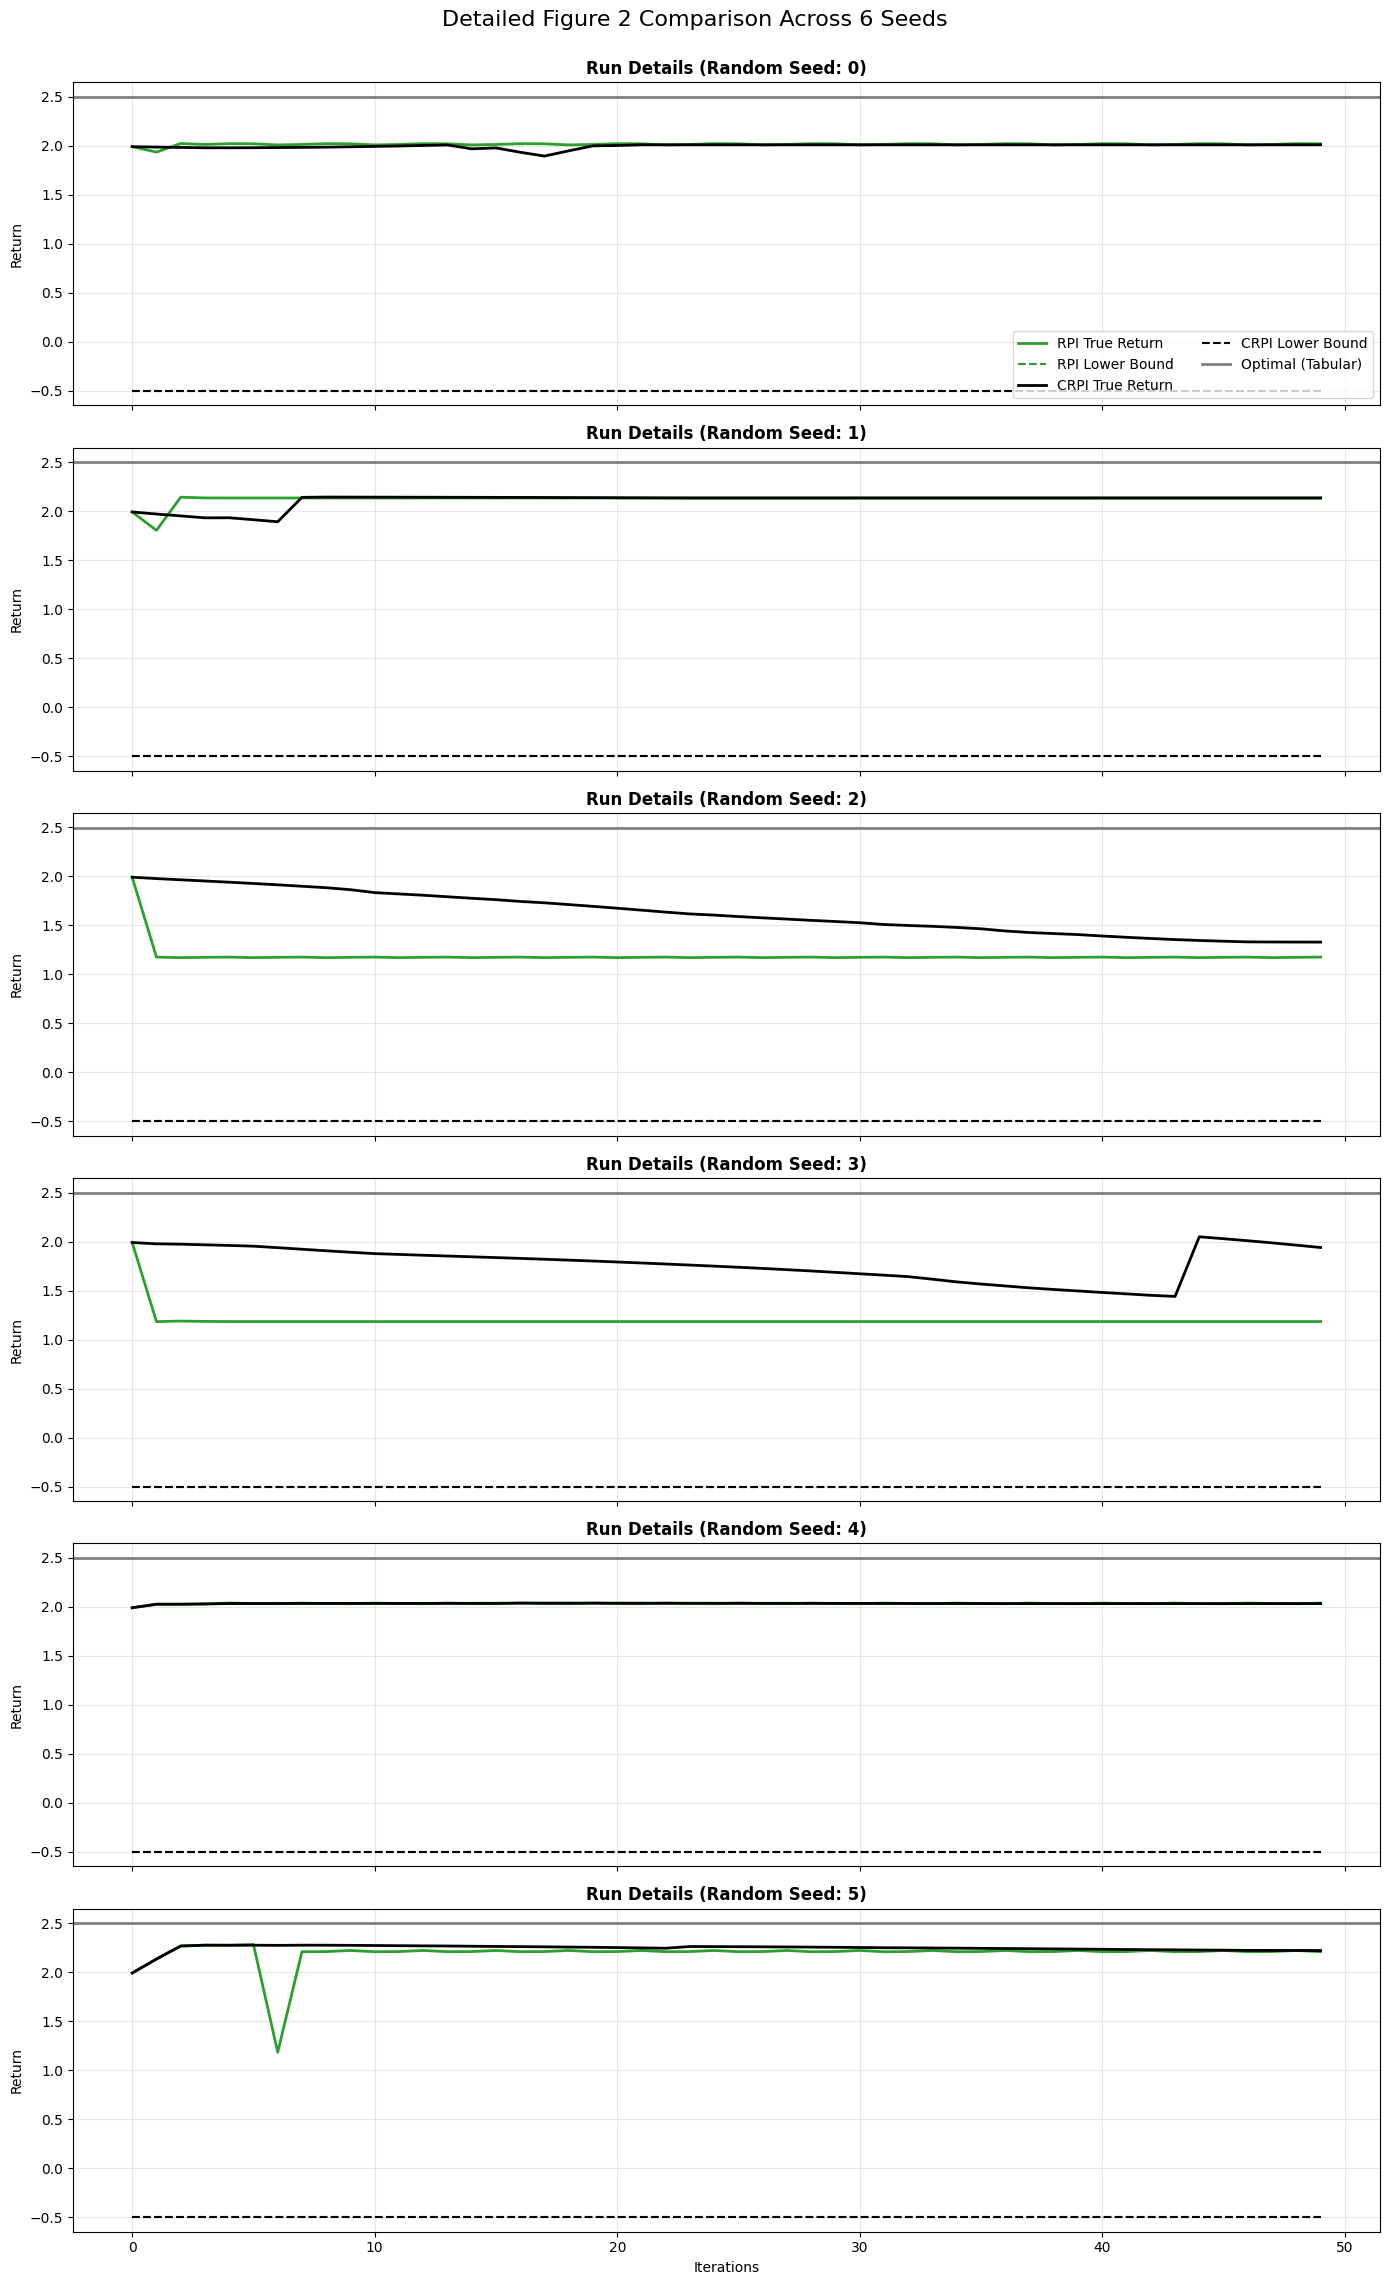

------------------------------
Average Terminal Performance across 6 Runs:
RPI: 1.794
CRPI: 1.945


In [ ]:
# --- CELL 3 ---
n_seeds = 6
# Store metrics for output
rpi_terminals = []
crpi_terminals = []

# Create a 5x1 grid of stacked subplots
fig, axes = plt.subplots(n_seeds, 1, figsize=(14, 4 * n_seeds), sharex=True)
fig.suptitle(f"Detailed Figure 2 Comparison Across {n_seeds} Seeds", fontsize=16)

print(f"Running {n_seeds} detailed runs. This will take a moment...")

# Loop through each seed to train and plot immediately
for i in range(n_seeds):
    seed = i  # Keep seed consistent with index
    ax = axes[i]  # Get the current subplot

    # -- Fixed-Seed Feature Generation --
    np.random.seed(seed)
    Phi = np.random.uniform(1, 5, size=(SA, d_features))
    Phi[:, 0] = 1.0  # Bias column fix

    # -- 1. Train RPI --
    rpi_agent = RPI(env, LinearFA(Phi), gamma, iters)
    # Refactored train call, extracting history
    _, _, rpi_hist = rpi_agent.train(track_metrics=True)
    rpi_terminals.append(rpi_hist['true_return'][-1])

    # -- 2. Train CRPI --
    crpi_agent = CRPI(env, LinearFA(Phi), gamma, iters)
    # Refactored train call, extracting history
    _, _, crpi_hist = crpi_agent.train(track_metrics=True)
    crpi_terminals.append(crpi_hist['true_return'][-1])

    # -- 3. Plotting Subplot (Strict Figure 2 Template) --
    # Plot RPI (Solid True, Dotted Estimated)
    ax.plot(rpi_hist['true_return'], color='#2ca02c', label='RPI True Return', linewidth=2)
    ax.plot(rpi_hist['est_return'], color='#2ca02c', linestyle='--', label='RPI Lower Bound')

    # Plot CRPI (Solid True, Dotted Estimated)
    ax.plot(crpi_hist['true_return'], color='#000000', label='CRPI True Return', linewidth=2)
    ax.plot(crpi_hist['est_return'], color='#000000', linestyle='--', label='CRPI Lower Bound')

    # Plot Optimal Baseline
    ax.axhline(optimal_return, color='gray', linewidth=2, linestyle='-', label='Optimal (Tabular)')

    # Labels and formatting for each subplot
    ax.set_title(f"Run Details (Random Seed: {seed})", fontweight='bold')
    ax.set_ylabel("Return")
    ax.grid(alpha=0.3)

    # Add legend only to the first subplot to reduce clutter
    if i == 0:
        ax.legend(loc='lower right', ncol=2)

# Set common x-label
axes[-1].set_xlabel("Iterations")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to fit main title
plt.show()

# -- 4. Output Summary Metrics --
print("-" * 30)
print(f"Average Terminal Performance across {n_seeds} Runs:")
print(f"RPI: {np.mean(rpi_terminals):.3f}")
print(f"CRPI: {np.mean(crpi_terminals):.3f}")

In [ ]:
# --- CELL 3 (Modified for Polynomial Degrees) ---
degrees = [2, 3, 4, 5, 6]
n_degrees = len(degrees)

# Store metrics for output
rpi_terminals = []
crpi_terminals = []

# Create a grid of stacked subplots based on the number of degrees
fig, axes = plt.subplots(n_degrees, 1, figsize=(14, 4 * n_degrees), sharex=True)
fig.suptitle(f"Detailed Figure 2 Comparison Across Polynomial Degrees", fontsize=16)

print(f"Running {n_degrees} detailed runs with varying polynomial degrees. This will take a moment...")

# -- Fixed Base Feature Generation --
# Generate base features once so the comparison across degrees is fair
np.random.seed(42)
# Note: Ensure 'SA' and 'd_features' (raw feature count) are defined in your notebook
Phi_raw = np.zeros((SA, d_features))

n_states = P.shape[0]
n_actions = P.shape[1]

row_idx = 0
for s in range(n_states):
    for a in range(n_actions):
        Phi[row_idx, 0] = 1.0  # Feature 1: Bias
        Phi[row_idx, 1] = s    # Feature 2: The actual state (e.g., Portfolio Value)
        Phi[row_idx, 2] = a    # Feature 3: The actual action (e.g., 0 or 1)
        row_idx += 1


# Loop through each degree to train and plot immediately
for i, deg in enumerate(degrees):
    ax = axes[i]  # Get the current subplot

    # -- 1. Train RPI --
    # Use PolynomialFA with the current degree
    rpi_agent = RPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
    _, _, rpi_hist = rpi_agent.train(track_metrics=True)
    rpi_terminals.append(rpi_hist['true_return'][-1])

    # -- 2. Train CRPI --
    crpi_agent = CRPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
    _, _, crpi_hist = crpi_agent.train(track_metrics=True)
    crpi_terminals.append(crpi_hist['true_return'][-1])

    # -- 3. Plotting Subplot (Strict Figure 2 Template) --
    # Plot RPI (Solid True, Dotted Estimated)
    ax.plot(rpi_hist['true_return'], color='#2ca02c', label='RPI True Return', linewidth=2)
    ax.plot(rpi_hist['est_return'], color='#2ca02c', linestyle='--', label='RPI Lower Bound')

    # Plot CRPI (Solid True, Dotted Estimated)
    ax.plot(crpi_hist['true_return'], color='#000000', label='CRPI True Return', linewidth=2)
    ax.plot(crpi_hist['est_return'], color='#000000', linestyle='--', label='CRPI Lower Bound')

    # Plot Optimal Baseline (Assuming optimal_return is defined earlier)
    ax.axhline(optimal_return, color='gray', linewidth=2, linestyle='-', label='Optimal (Tabular)')

    # Labels and formatting for each subplot
    ax.set_title(f"Run Details (Polynomial Degree: {deg})", fontweight='bold')
    ax.set_ylabel("Return")
    ax.grid(alpha=0.3)

    # Add legend only to the first subplot to reduce clutter
    if i == 0:
        ax.legend(loc='lower right', ncol=2)

# Set common x-label
axes[-1].set_xlabel("Iterations")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to fit main title
plt.show()

# -- 4. Output Summary Metrics --
print("-" * 30)
print(f"Terminal Performance across Polynomial Degrees:")
for idx, deg in enumerate(degrees):
    print(f"Degree {deg} -> RPI: {rpi_terminals[idx]:.3f} | CRPI: {crpi_terminals[idx]:.3f}")

print("-" * 30)
print(f"Average Terminal Performance:")
print(f"RPI Average: {np.mean(rpi_terminals):.3f}")
print(f"CRPI Average: {np.mean(crpi_terminals):.3f}")

NameError: name 'plt' is not defined

Running 5 detailed runs with varying polynomial degrees. This will take a moment...
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.


c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/50 completed.
RPI Iteration 34/50 completed.
RPI Iteration 35/50 completed.
RPI Iteration 36/50 completed.
RPI Iteration 37/50 completed.
RPI Iteration 38/50 completed.
RPI Iterati

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 7/50 | alpha_k = 0.0396
CRPI Iteration 8/50 | alpha_k = 0.0421
CRPI Iteration 9/50 | alpha_k = 0.0450
CRPI Iteration 10/50 | alpha_k = 0.0485
CRPI Iteration 11/50 | alpha_k = 0.0505
CRPI Iteration 12/50 | alpha_k = 0.0300
CRPI Iteration 13/50 | alpha_k = 0.0296
CRPI Iteration 14/50 | alpha_k = 0.0296
CRPI Iteration 15/50 | alpha_k = 0.0315
CRPI Iteration 16/50 | alpha_k = 0.0346
CRPI Iteration 17/50 | alpha_k = 0.0356
CRPI Iteration 18/50 | alpha_k = 0.0346
CRPI Iteration 19/50 | alpha_k = 0.0330
CRPI Iteration 20/50 | alpha_k = 0.0309
CRPI Iteration 21/50 | alpha_k = 0.0285
CRPI Iteration 22/50 | alpha_k = 0.0264
CRPI Iteration 23/50 | alpha_k = 0.0244
CRPI Iteration 24/50 | alpha_k = 0.0218
CRPI Iteration 25/50 | alpha_k = 0.0200
CRPI Iteration 26/50 | alpha_k = 0.0185
CRPI Iteration 27/50 | alpha_k = 0.0149
CRPI Iteration 28/50 | alpha_k = 0.0167
CRPI Iteration 29/50 | alpha_k = 0.0184
CRPI Iteration 30/50 | alpha_k = 0.0169
CRPI Iteration 31/50 | alpha_k = 0.0154
CRP

...

CRPI Iteration 1/50 | alpha_k = 0.0001
CRPI Iteration 2/50 | alpha_k = 0.0002
CRPI Iteration 3/50 | alpha_k = 0.0010
CRPI Iteration 4/50 | alpha_k = 0.0004
CRPI Iteration 5/50 | alpha_k = 0.0026
CRPI Iteration 6/50 | alpha_k = 0.0026
CRPI Iteration 7/50 | alpha_k = 0.0026
CRPI Iteration 8/50 | alpha_k = 0.0026
CRPI Iteration 9/50 | alpha_k = 0.0026
CRPI Iteration 10/50 | alpha_k = 0.0026
CRPI Iteration 11/50 | alpha_k = 0.0026
CRPI Iteration 12/50 | alpha_k = 0.0026
CRPI Iteration 13/50 | alpha_k = 0.0026
CRPI Iteration 14/50 | alpha_k = 0.0026
CRPI Iteration 15/50 | alpha_k = 0.0026
CRPI Iteration 16/50 | alpha_k = 0.0026
CRPI Iteration 17/50 | alpha_k = 0.0026
CRPI Iteration 18/50 | alpha_k = 0.0026
CRPI Iteration 19/50 | alpha_k = 0.0026
CRPI Iteration 20/50 | alpha_k = 0.0026
CRPI Iteration 21/50 | alpha_k = 0.0026
CRPI Iteration 22/50 | alpha_k = 0.0026
CRPI Iteration 23/50 | alpha_k = 0.0026
CRPI Iteration 24/50 | alpha_k = 0.0026
CRPI Iteration 25/50 | alpha_k = 0.0027
CRPI Iter

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 1/50 | alpha_k = 0.0004
CRPI Iteration 2/50 | alpha_k = 0.0004
CRPI Iteration 3/50 | alpha_k = 0.0004
CRPI Iteration 4/50 | alpha_k = 0.0004
CRPI Iteration 5/50 | alpha_k = 0.0004
CRPI Iteration 6/50 | alpha_k = 0.0004
CRPI Iteration 7/50 | alpha_k = 0.0004
CRPI Iteration 8/50 | alpha_k = 0.0004
CRPI Iteration 9/50 | alpha_k = 0.0004
CRPI Iteration 10/50 | alpha_k = 0.0004
CRPI Iteration 11/50 | alpha_k = 0.0004
CRPI Iteration 12/50 | alpha_k = 0.0004
CRPI Iteration 13/50 | alpha_k = 0.0004
CRPI Iteration 14/50 | alpha_k = 0.0004
CRPI Iteration 15/50 | alpha_k = 0.0004
CRPI Iteration 16/50 | alpha_k = 0.0004
CRPI Iteration 17/50 | alpha_k = 0.0004
CRPI Iteration 18/50 | alpha_k = 0.0004
CRPI Iteration 19/50 | alpha_k = 0.0004
CRPI Iteration 20/50 | alpha_k = 0.0004
CRPI Iteration 21/50 | alpha_k = 0.0004
CRPI Iteration 22/50 | alpha_k = 0.0004
CRPI Iteration 23/50 | alpha_k = 0.0004
CRPI Iteration 24/50 | alpha_k = 0.0004
CRPI Iteration 25/50 | alpha_k = 0.0004
CRPI Iter

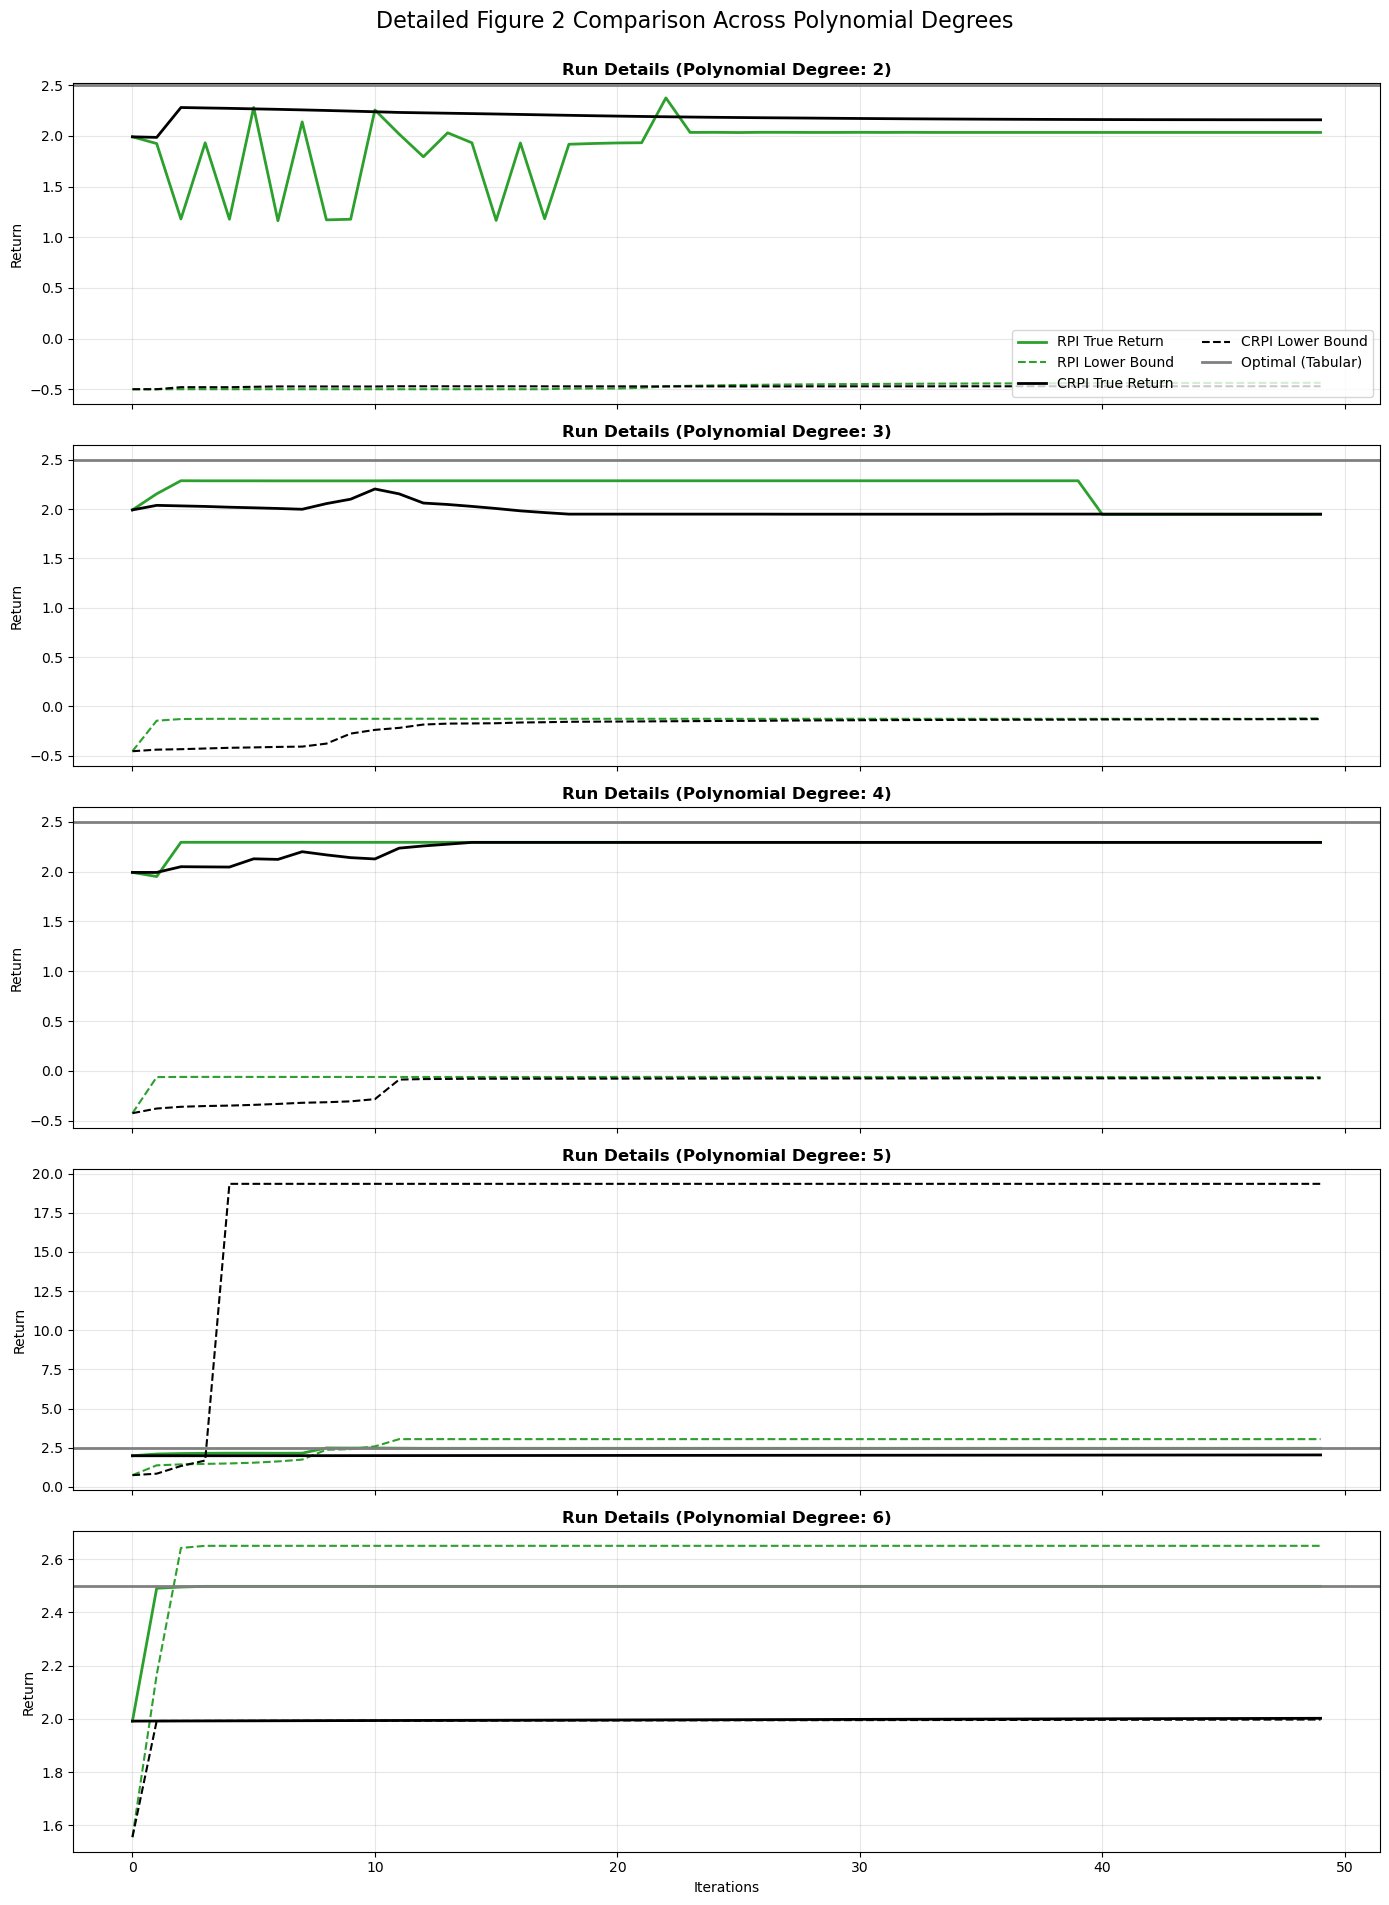

------------------------------
Terminal Performance across Polynomial Degrees:
Degree 2 -> RPI: 2.035 | CRPI: 2.159
Degree 3 -> RPI: 1.946 | CRPI: 1.949
Degree 4 -> RPI: 2.293 | CRPI: 2.293
Degree 5 -> RPI: 2.466 | CRPI: 2.042
Degree 6 -> RPI: 2.498 | CRPI: 2.002
------------------------------
Average Terminal Performance:
RPI Average: 2.248
CRPI Average: 2.089


In [ ]:
# --- CELL 3 (Modified for Polynomial Degrees) ---
degrees = [2, 3, 4, 5, 6]
n_degrees = len(degrees)

# Store metrics for output
rpi_terminals = []
crpi_terminals = []

# Create a grid of stacked subplots based on the number of degrees
fig, axes = plt.subplots(n_degrees, 1, figsize=(14, 4 * n_degrees), sharex=True)
fig.suptitle(f"Detailed Figure 2 Comparison Across Polynomial Degrees", fontsize=16)

print(f"Running {n_degrees} detailed runs with varying polynomial degrees. This will take a moment...")

# -- Fixed Base Feature Generation --
# Generate base features once so the comparison across degrees is fair
np.random.seed(42)
# Note: Ensure 'SA' and 'd_features' (raw feature count) are defined in your notebook
Phi_raw = np.random.uniform(1, 5, size=(SA, d_features))

# Loop through each degree to train and plot immediately
for i, deg in enumerate(degrees):
    ax = axes[i]  # Get the current subplot

    # -- 1. Train RPI --
    # Use PolynomialFA with the current degree
    rpi_agent = RPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
    _, _, rpi_hist = rpi_agent.train(track_metrics=True)
    rpi_terminals.append(rpi_hist['true_return'][-1])

    # -- 2. Train CRPI --
    crpi_agent = CRPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
    _, _, crpi_hist = crpi_agent.train(track_metrics=True)
    crpi_terminals.append(crpi_hist['true_return'][-1])

    # -- 3. Plotting Subplot (Strict Figure 2 Template) --
    # Plot RPI (Solid True, Dotted Estimated)
    ax.plot(rpi_hist['true_return'], color='#2ca02c', label='RPI True Return', linewidth=2)
    ax.plot(rpi_hist['est_return'], color='#2ca02c', linestyle='--', label='RPI Lower Bound')

    # Plot CRPI (Solid True, Dotted Estimated)
    ax.plot(crpi_hist['true_return'], color='#000000', label='CRPI True Return', linewidth=2)
    ax.plot(crpi_hist['est_return'], color='#000000', linestyle='--', label='CRPI Lower Bound')

    # Plot Optimal Baseline (Assuming optimal_return is defined earlier)
    ax.axhline(optimal_return, color='gray', linewidth=2, linestyle='-', label='Optimal (Tabular)')

    # Labels and formatting for each subplot
    ax.set_title(f"Run Details (Polynomial Degree: {deg})", fontweight='bold')
    ax.set_ylabel("Return")
    ax.grid(alpha=0.3)

    # Add legend only to the first subplot to reduce clutter
    if i == 0:
        ax.legend(loc='lower right', ncol=2)

# Set common x-label
axes[-1].set_xlabel("Iterations")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to fit main title
plt.show()

# -- 4. Output Summary Metrics --
print("-" * 30)
print(f"Terminal Performance across Polynomial Degrees:")
for idx, deg in enumerate(degrees):
    print(f"Degree {deg} -> RPI: {rpi_terminals[idx]:.3f} | CRPI: {crpi_terminals[idx]:.3f}")

print("-" * 30)
print(f"Average Terminal Performance:")
print(f"RPI Average: {np.mean(rpi_terminals):.3f}")
print(f"CRPI Average: {np.mean(crpi_terminals):.3f}")

Starting Polynomial Degree Sweep (2-6) with 5 seeds each...

RUNNING DEGREE: 2
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.


c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/50 completed.
RPI Iteration 34/50 completed.
RPI Iteration 35/50 completed.
RPI Iteration 36/50 completed.
RPI Iteration 37/50 completed.
RPI Iteratio

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 1/50 | alpha_k = 1.0000
CRPI Iteration 2/50 | alpha_k = 1.0000
CRPI Iteration 3/50 | alpha_k = 0.0181
CRPI Iteration 4/50 | alpha_k = 0.0340
CRPI Iteration 5/50 | alpha_k = 0.0382
CRPI Iteration 6/50 | alpha_k = 0.0457
CRPI Iteration 7/50 | alpha_k = 0.0180
CRPI Iteration 8/50 | alpha_k = 0.0182
CRPI Iteration 9/50 | alpha_k = 0.0462
CRPI Iteration 10/50 | alpha_k = 0.0452
CRPI Iteration 11/50 | alpha_k = 1.0000
CRPI Iteration 12/50 | alpha_k = 0.0166
CRPI Iteration 13/50 | alpha_k = 0.0345
CRPI Iteration 14/50 | alpha_k = 0.0557
CRPI Iteration 15/50 | alpha_k = 1.0000
CRPI Iteration 16/50 | alpha_k = 0.0244
CRPI Iteration 17/50 | alpha_k = 0.0140
CRPI Iteration 18/50 | alpha_k = 0.0183
CRPI Iteration 19/50 | alpha_k = 0.0215
CRPI Iteration 20/50 | alpha_k = 0.0563
CRPI Iteration 21/50 | alpha_k = 0.0118
CRPI Iteration 22/50 | alpha_k = 0.0279
CRPI Iteration 23/50 | alpha_k = 0.0228
CRPI Iteration 24/50 | alpha_k = 0.0595
CRPI Iteration 25/50 | alpha_k = 0.0237
CRPI Iter

...

CRPI Iteration 5/50 | alpha_k = 0.0218
CRPI Iteration 6/50 | alpha_k = 0.0226
CRPI Iteration 7/50 | alpha_k = 0.0227
CRPI Iteration 8/50 | alpha_k = 0.0233
CRPI Iteration 9/50 | alpha_k = 1.0000
CRPI Iteration 10/50 | alpha_k = 0.0410
CRPI Iteration 11/50 | alpha_k = 0.0149
CRPI Iteration 12/50 | alpha_k = 1.0000
CRPI Iteration 13/50 | alpha_k = 0.0177
CRPI Iteration 14/50 | alpha_k = 0.0186
CRPI Iteration 15/50 | alpha_k = 0.0207
CRPI Iteration 16/50 | alpha_k = 1.0000
CRPI Iteration 17/50 | alpha_k = 1.0000
CRPI Iteration 18/50 | alpha_k = 1.0000
CRPI Iteration 19/50 | alpha_k = 0.0160
CRPI Iteration 20/50 | alpha_k = 0.0162
CRPI Iteration 21/50 | alpha_k = 0.0164
CRPI Iteration 22/50 | alpha_k = 0.0168
CRPI Iteration 23/50 | alpha_k = 0.0169
CRPI Iteration 24/50 | alpha_k = 0.0172
CRPI Iteration 25/50 | alpha_k = 0.0175
CRPI Iteration 26/50 | alpha_k = 0.0185
CRPI Iteration 27/50 | alpha_k = 0.0194
CRPI Iteration 28/50 | alpha_k = 0.0191
CRPI Iteration 29/50 | alpha_k = 0.0188
CRPI 

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/50 completed.
RPI Iteration 34/50 completed.
RPI Iteration 35/50 completed.
RPI Iteration 36/50 completed.
RPI Iteration

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 3/50 | alpha_k = 0.0240
CRPI Iteration 4/50 | alpha_k = 0.0230
CRPI Iteration 5/50 | alpha_k = 0.0241
CRPI Iteration 6/50 | alpha_k = 0.0273
CRPI Iteration 7/50 | alpha_k = 0.0299
CRPI Iteration 8/50 | alpha_k = 0.0320
CRPI Iteration 9/50 | alpha_k = 0.0309
CRPI Iteration 10/50 | alpha_k = 0.0313
CRPI Iteration 11/50 | alpha_k = 0.0315
CRPI Iteration 12/50 | alpha_k = 0.0314
CRPI Iteration 13/50 | alpha_k = 0.0296
CRPI Iteration 14/50 | alpha_k = 0.0285
CRPI Iteration 15/50 | alpha_k = 0.0280
CRPI Iteration 16/50 | alpha_k = 0.0270
CRPI Iteration 17/50 | alpha_k = 0.0364
CRPI Iteration 18/50 | alpha_k = 0.0330
CRPI Iteration 19/50 | alpha_k = 0.0526
CRPI Iteration 20/50 | alpha_k = 0.0645
CRPI Iteration 21/50 | alpha_k = 0.0938
CRPI Iteration 22/50 | alpha_k = 0.0985
CRPI Iteration 23/50 | alpha_k = 0.1036
CRPI Iteration 24/50 | alpha_k = 0.1175
CRPI Iteration 25/50 | alpha_k = 0.1263
CRPI Iteration 26/50 | alpha_k = 0.1520
CRPI Iteration 27/50 | alpha_k = 0.1750
CRPI It

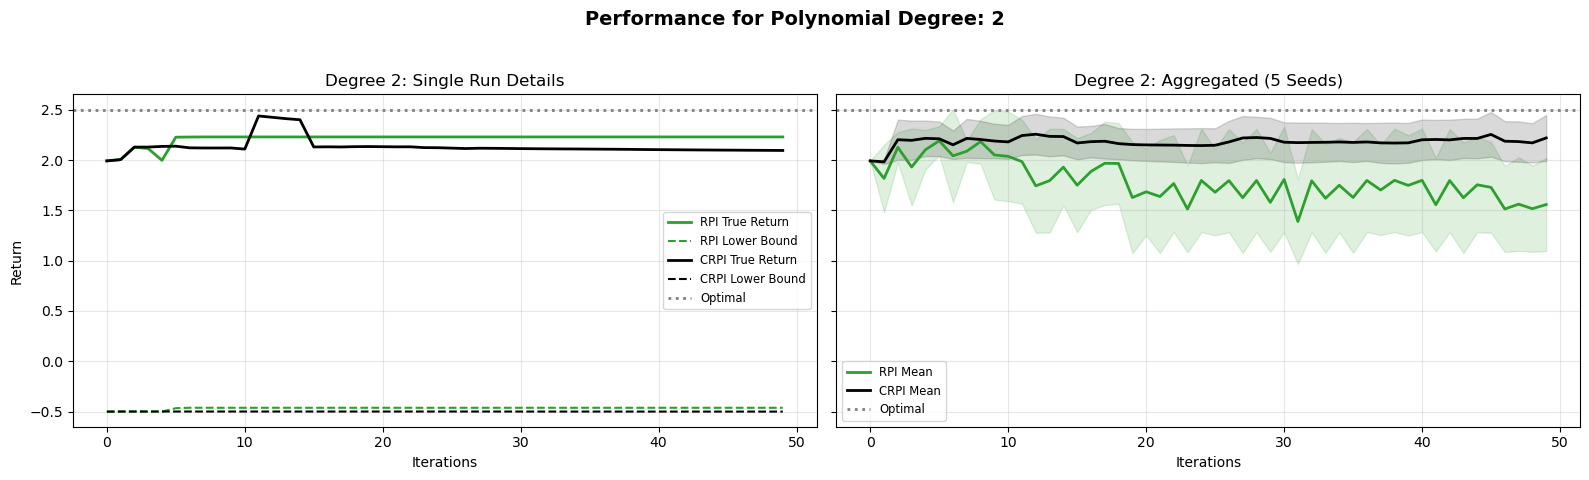

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,87.7 ± 16.2,1.56 ± 0.46
1,CRPI,107.0 ± 8.0,2.22 ± 0.23



RUNNING DEGREE: 3
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.


c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/50 completed.
RPI Iteration 34/50 completed.
RPI Iteration 3

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


...

CRPI Iteration 1/50 | alpha_k = 0.1037
CRPI Iteration 2/50 | alpha_k = 0.1138
CRPI Iteration 3/50 | alpha_k = 0.1278
CRPI Iteration 4/50 | alpha_k = 0.1475
CRPI Iteration 5/50 | alpha_k = 0.1744
CRPI Iteration 6/50 | alpha_k = 0.2121
CRPI Iteration 7/50 | alpha_k = 0.2834
CRPI Iteration 8/50 | alpha_k = 0.3630
CRPI Iteration 9/50 | alpha_k = 0.4964
CRPI Iteration 10/50 | alpha_k = 1.0000
CRPI Iteration 11/50 | alpha_k = 0.0374
CRPI Iteration 12/50 | alpha_k = 0.0384
CRPI Iteration 13/50 | alpha_k = 0.4442
CRPI Iteration 14/50 | alpha_k = 0.0666
CRPI Iteration 15/50 | alpha_k = 1.0000
CRPI Iteration 16/50 | alpha_k = 0.0707
CRPI Iteration 17/50 | alpha_k = 0.0745
CRPI Iteration 18/50 | alpha_k = 0.0612
CRPI Iteration 19/50 | alpha_k = 0.0658
CRPI Iteration 20/50 | alpha_k = 0.0677
CRPI Iteration 21/50 | alpha_k = 0.0577
CRPI Iteration 22/50 | alpha_k = 0.0614
CRPI Iteration 23/50 | alpha_k = 0.0658
CRPI Iteration 24/50 | alpha_k = 0.0705
CRPI Iteration 25/50 | alpha_k = 0.0756
CRPI Iter

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 3/50 | alpha_k = 0.0121
CRPI Iteration 4/50 | alpha_k = 0.0121
CRPI Iteration 5/50 | alpha_k = 0.0142
CRPI Iteration 6/50 | alpha_k = 0.0148
CRPI Iteration 7/50 | alpha_k = 0.0173
CRPI Iteration 8/50 | alpha_k = 0.0184
CRPI Iteration 9/50 | alpha_k = 0.0206
CRPI Iteration 10/50 | alpha_k = 0.0226
CRPI Iteration 11/50 | alpha_k = 0.0235
CRPI Iteration 12/50 | alpha_k = 0.0340
CRPI Iteration 13/50 | alpha_k = 0.0388
CRPI Iteration 14/50 | alpha_k = 0.0434
CRPI Iteration 15/50 | alpha_k = 0.0467
CRPI Iteration 16/50 | alpha_k = 0.0483
CRPI Iteration 17/50 | alpha_k = 0.0518
CRPI Iteration 18/50 | alpha_k = 0.0529
CRPI Iteration 19/50 | alpha_k = 0.0588
CRPI Iteration 20/50 | alpha_k = 0.0579
CRPI Iteration 21/50 | alpha_k = 0.0670
CRPI Iteration 22/50 | alpha_k = 0.0757
CRPI Iteration 23/50 | alpha_k = 0.0956
CRPI Iteration 24/50 | alpha_k = 0.0808
CRPI Iteration 25/50 | alpha_k = 0.2551
CRPI Iteration 26/50 | alpha_k = 0.3060
CRPI Iteration 27/50 | alpha_k = 1.0000
CRPI It

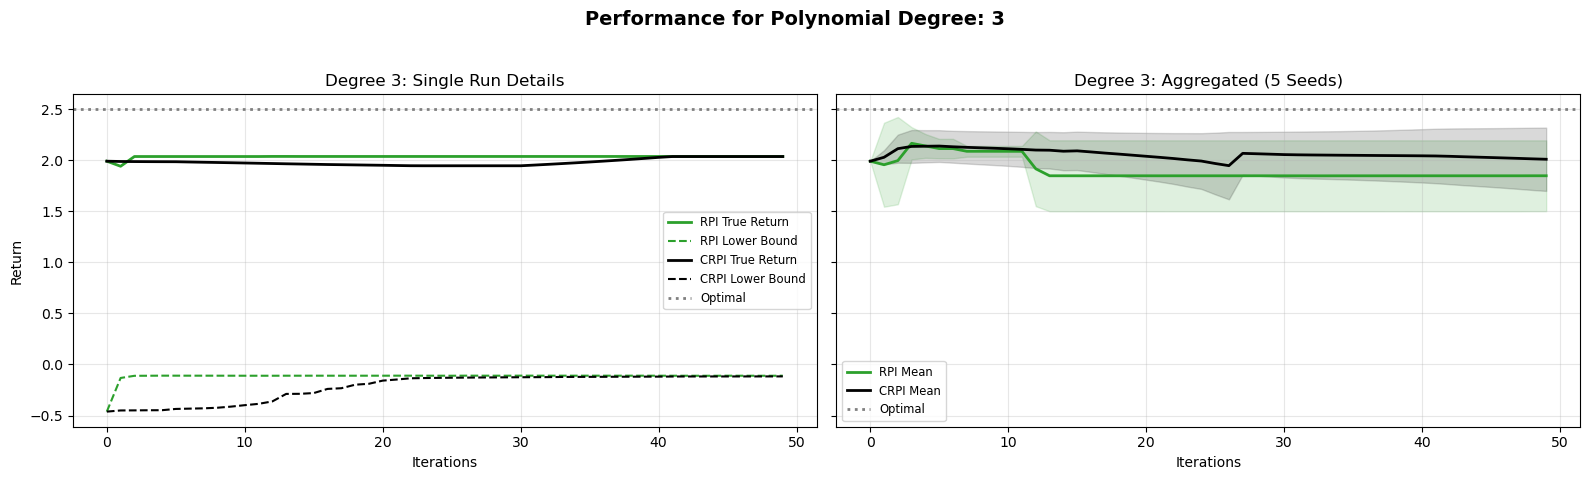

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,93.3 ± 13.1,1.85 ± 0.35
1,CRPI,100.9 ± 9.7,2.01 ± 0.31



RUNNING DEGREE: 4
RPI Iteration 1/50 completed.


c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/50 completed.
RPI Iteration 34

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


...

CRPI Iteration 2/50 | alpha_k = 0.0534
CRPI Iteration 3/50 | alpha_k = 0.0581
CRPI Iteration 4/50 | alpha_k = 0.0634
CRPI Iteration 5/50 | alpha_k = 0.0694
CRPI Iteration 6/50 | alpha_k = 0.0761
CRPI Iteration 7/50 | alpha_k = 0.0849
CRPI Iteration 8/50 | alpha_k = 0.1028
CRPI Iteration 9/50 | alpha_k = 0.1143
CRPI Iteration 10/50 | alpha_k = 0.1406
CRPI Iteration 11/50 | alpha_k = 0.1768
CRPI Iteration 12/50 | alpha_k = 0.2220
CRPI Iteration 13/50 | alpha_k = 0.1716
CRPI Iteration 14/50 | alpha_k = 0.0278
CRPI Iteration 15/50 | alpha_k = 0.0285
CRPI Iteration 16/50 | alpha_k = 0.0273
CRPI Iteration 17/50 | alpha_k = 0.0275
CRPI Iteration 18/50 | alpha_k = 0.0285
CRPI Iteration 19/50 | alpha_k = 0.0277
CRPI Iteration 20/50 | alpha_k = 0.0278
CRPI Iteration 21/50 | alpha_k = 0.0279
CRPI Iteration 22/50 | alpha_k = 0.0282
CRPI Iteration 23/50 | alpha_k = 0.0287
CRPI Iteration 24/50 | alpha_k = 0.0292
CRPI Iteration 25/50 | alpha_k = 0.0299
CRPI Iteration 26/50 | alpha_k = 0.0295
CRPI Ite

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/50 completed.
RPI Iteration 34

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 2/50 | alpha_k = 0.1008
CRPI Iteration 3/50 | alpha_k = 0.5542
CRPI Iteration 4/50 | alpha_k = 0.3481
CRPI Iteration 5/50 | alpha_k = 0.2638
CRPI Iteration 6/50 | alpha_k = 0.0954
CRPI Iteration 7/50 | alpha_k = 0.2192
CRPI Iteration 8/50 | alpha_k = 0.3283
CRPI Iteration 9/50 | alpha_k = 0.3793
CRPI Iteration 10/50 | alpha_k = 0.0877
CRPI Iteration 11/50 | alpha_k = 0.1148
CRPI Iteration 12/50 | alpha_k = 0.0307
CRPI Iteration 13/50 | alpha_k = 0.0433
CRPI Iteration 14/50 | alpha_k = 0.0062
CRPI Iteration 15/50 | alpha_k = 0.0461
CRPI Iteration 16/50 | alpha_k = 0.0654
CRPI Iteration 17/50 | alpha_k = 0.0556
CRPI Iteration 18/50 | alpha_k = 0.0528
CRPI Iteration 19/50 | alpha_k = 0.0596
CRPI Iteration 20/50 | alpha_k = 0.0555
CRPI Iteration 21/50 | alpha_k = 0.0565
CRPI Iteration 22/50 | alpha_k = 0.0294
CRPI Iteration 23/50 | alpha_k = 0.0435
CRPI Iteration 24/50 | alpha_k = 0.0472
CRPI Iteration 25/50 | alpha_k = 0.0528
CRPI Iteration 26/50 | alpha_k = 0.0124
CRPI Ite

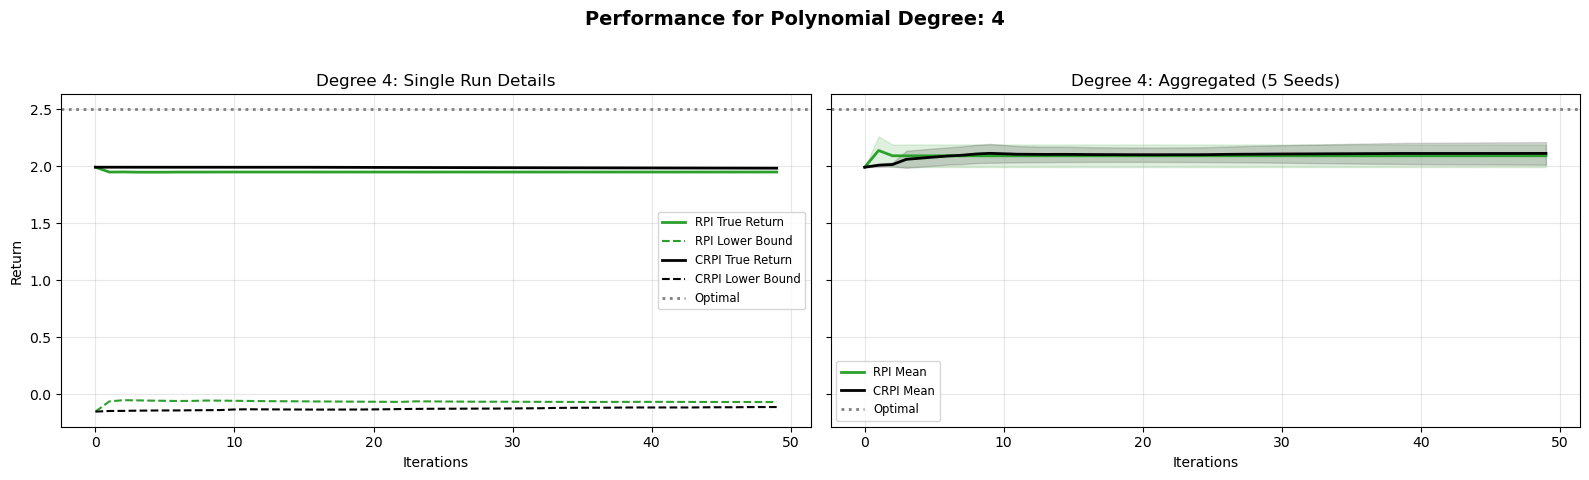

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,102.5 ± 4.8,2.09 ± 0.10
1,CRPI,102.9 ± 3.2,2.11 ± 0.10



RUNNING DEGREE: 5


c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


...

CRPI Iteration 1/50 | alpha_k = 0.0031
CRPI Iteration 2/50 | alpha_k = 0.0018
CRPI Iteration 3/50 | alpha_k = 0.0013
CRPI Iteration 4/50 | alpha_k = 0.0010
CRPI Iteration 5/50 | alpha_k = 0.0007
CRPI Iteration 6/50 | alpha_k = 0.0005
CRPI Iteration 7/50 | alpha_k = 0.0005
CRPI Iteration 8/50 | alpha_k = 0.0006
CRPI Iteration 9/50 | alpha_k = 0.0004
CRPI Iteration 10/50 | alpha_k = 0.0005
CRPI Iteration 11/50 | alpha_k = 0.0005
CRPI Iteration 12/50 | alpha_k = 0.0005
CRPI Iteration 13/50 | alpha_k = 0.0004
CRPI Iteration 14/50 | alpha_k = 0.0006
CRPI Iteration 15/50 | alpha_k = 0.0007
CRPI Iteration 16/50 | alpha_k = 0.0006
CRPI Iteration 17/50 | alpha_k = 0.0006
CRPI Iteration 18/50 | alpha_k = 0.0008
CRPI Iteration 19/50 | alpha_k = 0.0005
CRPI Iteration 20/50 | alpha_k = 0.0006
CRPI Iteration 21/50 | alpha_k = 0.0007
CRPI Iteration 22/50 | alpha_k = 0.0012
CRPI Iteration 23/50 | alpha_k = 0.0012
CRPI Iteration 24/50 | alpha_k = 0.0012
CRPI Iteration 25/50 | alpha_k = 0.0012
CRPI Iter

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 1/50 | alpha_k = 0.0003
CRPI Iteration 2/50 | alpha_k = 0.0003
CRPI Iteration 3/50 | alpha_k = 0.0003
CRPI Iteration 4/50 | alpha_k = 0.0003
CRPI Iteration 5/50 | alpha_k = 0.0003
CRPI Iteration 6/50 | alpha_k = 0.0003
CRPI Iteration 7/50 | alpha_k = 0.0003
CRPI Iteration 8/50 | alpha_k = 0.0002
CRPI Iteration 9/50 | alpha_k = 0.0003
CRPI Iteration 10/50 | alpha_k = 0.0003
CRPI Iteration 11/50 | alpha_k = 0.0003
CRPI Iteration 12/50 | alpha_k = 0.0003
CRPI Iteration 13/50 | alpha_k = 0.0002
CRPI Iteration 14/50 | alpha_k = 0.0003
CRPI Iteration 15/50 | alpha_k = 0.0003
CRPI Iteration 16/50 | alpha_k = 0.0003
CRPI Iteration 17/50 | alpha_k = 0.0003
CRPI Iteration 18/50 | alpha_k = 0.0002
CRPI Iteration 19/50 | alpha_k = 0.0003
CRPI Iteration 20/50 | alpha_k = 0.0002
CRPI Iteration 21/50 | alpha_k = 0.0002
CRPI Iteration 22/50 | alpha_k = 0.0002
CRPI Iteration 23/50 | alpha_k = 0.0002
CRPI Iteration 24/50 | alpha_k = 0.0003
CRPI Iteration 25/50 | alpha_k = 0.0002
CRPI Iter

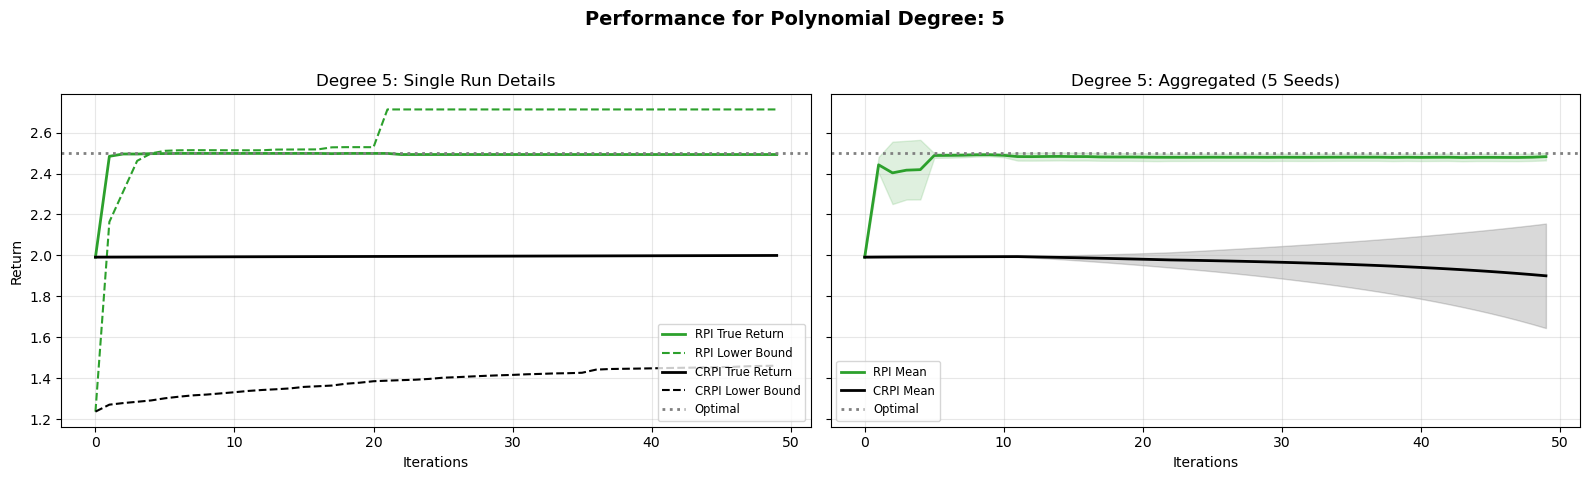

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,121.1 ± 1.2,2.48 ± 0.02
1,CRPI,96.4 ± 3.6,1.90 ± 0.26



RUNNING DEGREE: 6
RPI Iteration 1/50 completed.


c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/50 completed.
RPI Iteration 34

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


...

CRPI Iteration 1/50 | alpha_k = 0.0006
CRPI Iteration 2/50 | alpha_k = 0.0005
CRPI Iteration 3/50 | alpha_k = 0.0005
CRPI Iteration 4/50 | alpha_k = 0.0005
CRPI Iteration 5/50 | alpha_k = 0.0005
CRPI Iteration 6/50 | alpha_k = 0.0005
CRPI Iteration 7/50 | alpha_k = 0.0005
CRPI Iteration 8/50 | alpha_k = 0.0005
CRPI Iteration 9/50 | alpha_k = 0.0005
CRPI Iteration 10/50 | alpha_k = 0.0005
CRPI Iteration 11/50 | alpha_k = 0.0005
CRPI Iteration 12/50 | alpha_k = 0.0005
CRPI Iteration 13/50 | alpha_k = 0.0005
CRPI Iteration 14/50 | alpha_k = 0.0005
CRPI Iteration 15/50 | alpha_k = 0.0005
CRPI Iteration 16/50 | alpha_k = 0.0005
CRPI Iteration 17/50 | alpha_k = 0.0005
CRPI Iteration 18/50 | alpha_k = 0.0005
CRPI Iteration 19/50 | alpha_k = 0.0005
CRPI Iteration 20/50 | alpha_k = 0.0005
CRPI Iteration 21/50 | alpha_k = 0.0005
CRPI Iteration 22/50 | alpha_k = 0.0005
CRPI Iteration 23/50 | alpha_k = 0.0005
CRPI Iteration 24/50 | alpha_k = 0.0005
CRPI Iteration 25/50 | alpha_k = 0.0005
CRPI Iter

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/

c:\Users\shree\OneDrive\Desktop\IIIT\3-2\RL\TabularRL_DiscountFactors\function_approximation\linear_fa.py:49: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=2000)


CRPI Iteration 1/50 | alpha_k = 0.0004
CRPI Iteration 2/50 | alpha_k = 0.0004
CRPI Iteration 3/50 | alpha_k = 0.0004
CRPI Iteration 4/50 | alpha_k = 0.0004
CRPI Iteration 5/50 | alpha_k = 0.0004
CRPI Iteration 6/50 | alpha_k = 0.0004
CRPI Iteration 7/50 | alpha_k = 0.0004
CRPI Iteration 8/50 | alpha_k = 0.0004
CRPI Iteration 9/50 | alpha_k = 0.0004
CRPI Iteration 10/50 | alpha_k = 0.0004
CRPI Iteration 11/50 | alpha_k = 0.0004
CRPI Iteration 12/50 | alpha_k = 0.0004
CRPI Iteration 13/50 | alpha_k = 0.0004
CRPI Iteration 14/50 | alpha_k = 0.0004
CRPI Iteration 15/50 | alpha_k = 0.0004
CRPI Iteration 16/50 | alpha_k = 0.0004
CRPI Iteration 17/50 | alpha_k = 0.0004
CRPI Iteration 18/50 | alpha_k = 0.0004
CRPI Iteration 19/50 | alpha_k = 0.0004
CRPI Iteration 20/50 | alpha_k = 0.0004
CRPI Iteration 21/50 | alpha_k = 0.0004
CRPI Iteration 22/50 | alpha_k = 0.0004
CRPI Iteration 23/50 | alpha_k = 0.0004
CRPI Iteration 24/50 | alpha_k = 0.0004
CRPI Iteration 25/50 | alpha_k = 0.0004
CRPI Iter

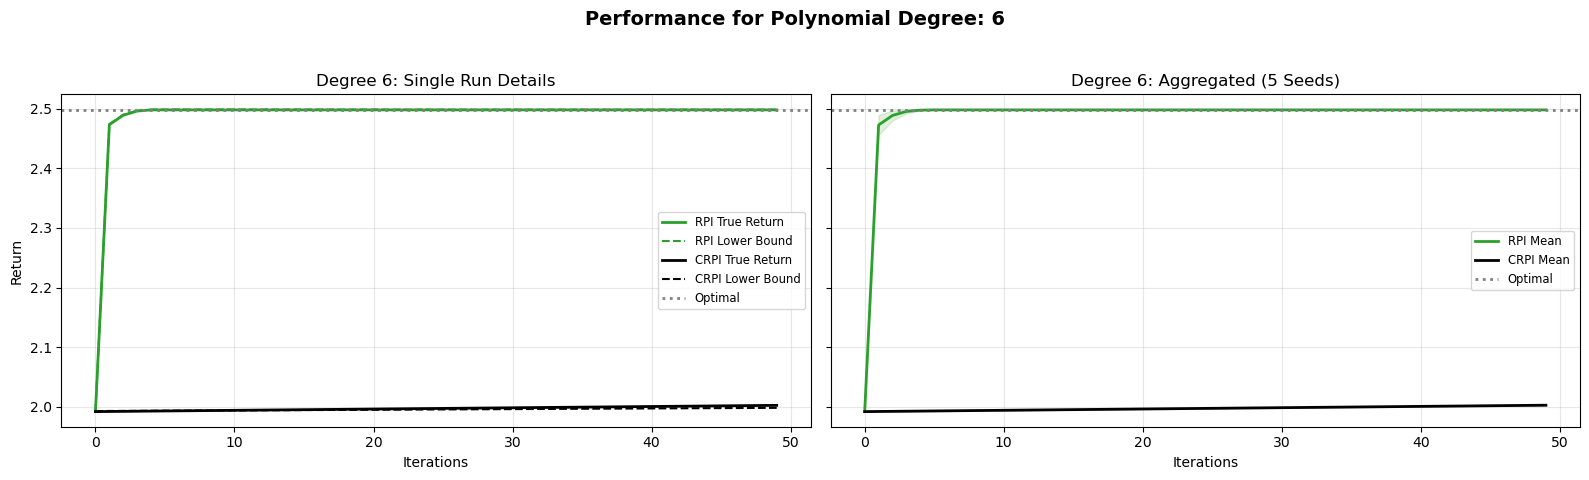

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,122.1 ± 0.0,2.50 ± 0.00
1,CRPI,97.8 ± 0.0,2.00 ± 0.00


In [4]:
# Configuration
degrees = range(2, 7) # Degrees 2, 3, 4, 5, 6
n_seeds = 5           # Reduced seeds slightly for speed across multiple degrees
iters = 50            # Ensure this matches your iters variable

print(f"Starting Polynomial Degree Sweep (2-6) with {n_seeds} seeds each...")

# --- OUTER LOOP: POLYNOMIAL DEGREES ---
for deg in degrees:
    print(f"\n" + "="*50)
    print(f"RUNNING DEGREE: {deg}")
    print("="*50)
    
    rpi_all_true = []
    crpi_all_true = []
    
    # Store history for seed 0 plotting
    rpi_seed0_true, rpi_seed0_est = None, None
    crpi_seed0_true, crpi_seed0_est = None, None

    # --- INNER LOOP: SEEDS ---
    for seed in range(n_seeds):
        np.random.seed(seed)
        # Generate base raw features (SA and d_features must be defined in your env)
        Phi_raw = np.random.uniform(1, 5, size=(SA, d_features))
        
        # 1. Train RPI with PolynomialFA
        rpi_agent = RPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
        _, _, r_hist = rpi_agent.train(track_metrics=True)
        rpi_all_true.append(r_hist['true_return'])

        # 2. Train CRPI with PolynomialFA
        crpi_agent = CRPI(env, PolynomialFA(Phi_raw, degree=deg), gamma, iters)
        _, _, c_hist = crpi_agent.train(track_metrics=True)
        crpi_all_true.append(c_hist['true_return'])

        # Save the very first seed's history for the single-run subplot
        if seed == 0:
            rpi_seed0_true = r_hist['true_return']
            rpi_seed0_est = r_hist['est_return']
            crpi_seed0_true = c_hist['true_return']
            crpi_seed0_est = c_hist['est_return']

    # Convert to numpy arrays for calculation
    rpi_all_true = np.array(rpi_all_true)
    crpi_all_true = np.array(crpi_all_true)

    # --- 3. PLOTTING FOR CURRENT DEGREE ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    fig.suptitle(f"Performance for Polynomial Degree: {deg}", fontsize=14, fontweight='bold')

    # Subplot 1: Single Run Overlay (Seed 0)
    ax1.plot(rpi_seed0_true, color='#2ca02c', label='RPI True Return', linewidth=2)
    ax1.plot(rpi_seed0_est, color='#2ca02c', linestyle='--', label='RPI Lower Bound')
    ax1.plot(crpi_seed0_true, color='#000000', label='CRPI True Return', linewidth=2)
    ax1.plot(crpi_seed0_est, color='#000000', linestyle='--', label='CRPI Lower Bound')
    ax1.axhline(optimal_return, color='gray', linewidth=2, linestyle=':', label='Optimal')
    ax1.set_title(f"Degree {deg}: Single Run Details")
    ax1.set_xlabel("Iterations")
    ax1.set_ylabel("Return")
    ax1.legend(fontsize='small')
    ax1.grid(alpha=0.3)

    # Subplot 2: Aggregated (Mean ± Std Dev)
    rpi_mean, rpi_std = np.mean(rpi_all_true, axis=0), np.std(rpi_all_true, axis=0)
    crpi_mean, crpi_std = np.mean(crpi_all_true, axis=0), np.std(crpi_all_true, axis=0)

    ax2.plot(rpi_mean, color='#2ca02c', label='RPI Mean', linewidth=2)
    ax2.fill_between(range(iters), rpi_mean - rpi_std, rpi_mean + rpi_std, color='#2ca02c', alpha=0.15)
    ax2.plot(crpi_mean, color='#000000', label='CRPI Mean', linewidth=2)
    ax2.fill_between(range(iters), crpi_mean - crpi_std, crpi_mean + crpi_std, color='#000000', alpha=0.15)
    ax2.axhline(optimal_return, color='gray', linewidth=2, linestyle=':', label='Optimal')
    ax2.set_title(f"Degree {deg}: Aggregated ({n_seeds} Seeds)")
    ax2.set_xlabel("Iterations")
    ax2.legend(fontsize='small')
    ax2.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- 4. GENERATE METRICS TABLE FOR CURRENT DEGREE ---
    # Using np.trapezoid (or np.trapz for older numpy versions)
    rpi_aucs = [np.trapezoid(run) for run in rpi_all_true]
    crpi_aucs = [np.trapezoid(run) for run in crpi_all_true]

    metrics_data = {
        "Algorithm": ["RPI", "CRPI"],
        "AUC (mean ± std)": [f"{np.mean(rpi_aucs):.1f} ± {np.std(rpi_aucs):.1f}",
                             f"{np.mean(crpi_aucs):.1f} ± {np.std(crpi_aucs):.1f}"],
        "Terminal Perf. (mean ± std)": [f"{rpi_mean[-1]:.2f} ± {rpi_std[-1]:.2f}",
                                        f"{crpi_mean[-1]:.2f} ± {crpi_std[-1]:.2f}"]
    }
    display(pd.DataFrame(metrics_data))